<a href="https://colab.research.google.com/github/subudear/deep-learning/blob/main/assignment2/partB_method1/B1_01_generate_synthetic_audio_audioldm2_v2_class_aware.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B1-01 — Generate synthetic-balanced audio with AudioLDM2  
## Part B Method 1: Synthetic-balanced data → BirdNET embeddings → ML classifier

This notebook creates the **synthetic audio dataset** for **Option B Method 1**.

It does **not** train a model and it does **not** extract BirdNET embeddings.  
Those are handled by the next notebooks:

- **B1-02**: extract BirdNET embeddings from generated synthetic audio
- **B1-03**: train ML classifiers using original train embeddings + synthetic train embeddings

## Key design decisions

- Synthetic files are saved as **WAV**. Your original files are `.ogg`, but for embedding extraction the file container does not matter as long as BirdNET/librosa can decode the audio. WAV is simpler and safer for generated waveform output.
- Synthetic data is used for **training only**.
- Validation remains the same original validation split used for A Method 1.
- Generation is **resume-safe**. If the notebook stops, rerun it and completed files are skipped.
- Prompt generation is **class-aware** using your `train.csv` columns:
  - `primary_label`
  - `common_name`
  - `scientific_name`
  - `class_name`

## 1. Mount Google Drive

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Install dependencies

Use a GPU runtime if possible:  
`Runtime > Change runtime type > T4 GPU`

In [14]:
!pip install -q --upgrade diffusers transformers accelerate
!pip install -q soundfile scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

## 3. Imports and configuration

All new Part B Method 1 files are stored under:

```text
/content/drive/MyDrive/audio_assignment/PartB_Method1
```

The original A Method 1 embeddings remain at:

```text
/content/drive/MyDrive/audio_assignment/zip/embeddings/birdnet_original_mean
```

In [15]:
from pathlib import Path
import os
import re
import json
import time
import math
import hashlib
import traceback
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import soundfile as sf

# ---------------------------------------------------------------------
# Required original inputs
# ---------------------------------------------------------------------
ORIGINAL_METADATA_PATH = Path("/content/drive/MyDrive/audio_assignment/zip/train.csv")
ORIGINAL_EMBEDDINGS_DIR = Path("/content/drive/MyDrive/audio_assignment/zip/embeddings/birdnet_original_mean")

# ---------------------------------------------------------------------
# Part B Method 1 output root
# ---------------------------------------------------------------------
PARTB_DIR = Path("/content/drive/MyDrive/audio_assignment/PartB_Method1")
SYNTH_AUDIO_DIR = PARTB_DIR / "synthetic_audio"
METADATA_DIR = PARTB_DIR / "metadata"
STATUS_DIR = PARTB_DIR / "status"
PLOTS_DIR = PARTB_DIR / "plots"

for p in [PARTB_DIR, SYNTH_AUDIO_DIR, METADATA_DIR, STATUS_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# AudioLDM2 settings
# ---------------------------------------------------------------------
MODEL_ID = "cvssp/audioldm2"   # Base AudioLDM2; faster than large variants.
OUTPUT_FORMAT = "wav"
OUTPUT_SAMPLE_RATE = 16000     # AudioLDM2 examples commonly save at 16 kHz.
AUDIO_DURATION_SECONDS = 5.0

# Lower steps = faster, lower quality. Increase to 40-50 if time allows.
NUM_INFERENCE_STEPS = 25
GUIDANCE_SCALE = 3.5

# ---------------------------------------------------------------------
# Synthetic balancing settings
# ---------------------------------------------------------------------
# Controlled first run to save time.
# The plan prioritises validation-only classes and rare training classes.
TARGET_MIN_PER_CLASS = 10
MAX_SYNTH_PER_CLASS = 10
MAX_TOTAL_SYNTH_FILES = 500

# Optional limit per notebook execution.
# None means run all pending planned files.
MAX_FILES_THIS_RUN = None

# Set True only if you want to discard and rebuild the synthetic plan before generation starts.
# Leave False for normal resume-safe operation.
REBUILD_GENERATION_PLAN = False

# Resume behaviour
SKIP_EXISTING_AUDIO = True

# Deterministic seed base
BASE_SEED = 42

print("Part B Method 1 folder:", PARTB_DIR)
print("Original metadata path:", ORIGINAL_METADATA_PATH, "exists:", ORIGINAL_METADATA_PATH.exists())
print("Original embeddings dir:", ORIGINAL_EMBEDDINGS_DIR, "exists:", ORIGINAL_EMBEDDINGS_DIR.exists())
print("Synthetic audio dir:", SYNTH_AUDIO_DIR)
print("Using device:", "cuda" if torch.cuda.is_available() else "cpu")

Part B Method 1 folder: /content/drive/MyDrive/audio_assignment/PartB_Method1
Original metadata path: /content/drive/MyDrive/audio_assignment/zip/train.csv exists: True
Original embeddings dir: /content/drive/MyDrive/audio_assignment/zip/embeddings/birdnet_original_mean exists: True
Synthetic audio dir: /content/drive/MyDrive/audio_assignment/PartB_Method1/synthetic_audio
Using device: cpu


## 4. Helper functions

In [16]:
def now_iso():
    return datetime.now().isoformat(timespec="seconds")


def safe_slug(text, max_len=80):
    text = str(text)
    text = text.strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    if not text:
        text = "unknown"
    return text[:max_len]


def stable_seed(*parts, base_seed=BASE_SEED):
    joined = "::".join(str(p) for p in parts)
    digest = hashlib.md5(joined.encode("utf-8")).hexdigest()
    return int(digest[:8], 16) + int(base_seed)


def find_one_file(base_dir: Path, exact_names=None, patterns=None, required=True, label="file"):
    exact_names = exact_names or []
    patterns = patterns or []

    for name in exact_names:
        p = base_dir / name
        if p.exists():
            return p

    hits = []
    for pat in patterns:
        hits.extend(sorted(base_dir.glob(pat)))

    hits = [h for h in hits if "chunks" not in str(h).lower()]

    if hits:
        if len(hits) > 1:
            print(f"Multiple candidates for {label}; using first:")
            for h in hits[:10]:
                print("  ", h.name)
        return hits[0]

    if required:
        raise FileNotFoundError(
            f"Could not find {label} in {base_dir}. "
            f"Tried exact names={exact_names}, patterns={patterns}"
        )
    return None


def load_array(path: Path):
    if path.suffix.lower() == ".npy":
        return np.load(path, allow_pickle=True)
    if path.suffix.lower() == ".npz":
        data = np.load(path, allow_pickle=True)
        keys = list(data.keys())
        for k in ["arr_0", "X", "x", "embeddings", "features", "y", "labels"]:
            if k in data:
                return data[k]
        return data[keys[0]]
    raise ValueError(f"Unsupported array file type: {path}")


def clean_prompt_label(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    x = re.sub(r"[_\\-]+", " ", x)
    x = re.sub(r"\\s+", " ", x)
    return x.strip()


def looks_numeric_label(x):
    x = str(x).strip()
    return bool(re.fullmatch(r"\\d+", x))


def build_prompt(prompt_label, class_name=None, scientific_name=None):
    prompt_label = clean_prompt_label(prompt_label)
    scientific_name = clean_prompt_label(scientific_name)
    class_name = "" if pd.isna(class_name) else str(class_name).strip()

    # Prefer common name, but include scientific name if useful and different.
    label_text = prompt_label
    if scientific_name and scientific_name.lower() != prompt_label.lower():
        label_text = f"{prompt_label} ({scientific_name})"

    if not label_text or looks_numeric_label(label_text):
        label_text = "wildlife"

    if class_name == "Aves":
        return (
            f"A clear realistic field recording of a {label_text} bird vocalisation, "
            f"natural bird call or bird song, single target bird, outdoor habitat, "
            f"bioacoustic recording, no human speech, no music."
        )

    if class_name == "Amphibia":
        return (
            f"A clear realistic field recording of a {label_text} frog or amphibian vocalisation, "
            f"natural frog call, single target animal, wetland or outdoor habitat, "
            f"bioacoustic recording, no human speech, no music."
        )

    if class_name == "Insecta":
        return (
            f"A clear realistic field recording of a {label_text} insect sound, "
            f"natural insect call, chirp or buzz, single target insect, outdoor habitat, "
            f"bioacoustic recording, no human speech, no music."
        )

    if class_name == "Mammalia":
        return (
            f"A clear realistic field recording of a {label_text} mammal vocalisation, "
            f"natural animal call, single target mammal, outdoor habitat, "
            f"bioacoustic recording, no human speech, no music."
        )

    if class_name == "Reptilia":
        return (
            f"A clear realistic field recording of a {label_text} reptile or caiman vocalisation, "
            f"natural animal sound, single target reptile, outdoor habitat, "
            f"bioacoustic recording, no human speech, no music."
        )

    return (
        f"A clear realistic field recording of a {label_text} animal vocalisation, "
        f"natural wildlife sound, single target animal, outdoor habitat, "
        f"bioacoustic recording, no human speech, no music."
    )


NEGATIVE_PROMPT = (
    "human speech, talking, music, instruments, traffic, engine, urban noise, "
    "rainstorm, wind overload, clipping, distortion, low quality, multiple species"
)

## 5. Load original A Method 1 train/validation labels

This notebook uses the same split already used by A Method 1.

It loads:

```text
y_train
y_validation
```

from:

```text
/content/drive/MyDrive/audio_assignment/zip/embeddings/birdnet_original_mean
```

In [17]:
y_train_path = find_one_file(
    ORIGINAL_EMBEDDINGS_DIR,
    exact_names=["y_train.npy", "train_labels.npy", "labels_train.npy", "y_train_all.npy"],
    patterns=["*y_train*.npy", "*train*label*.npy", "*labels_train*.npy", "*y_train*.npz"],
    label="y_train"
)

y_val_path = find_one_file(
    ORIGINAL_EMBEDDINGS_DIR,
    exact_names=["y_validation.npy", "y_val.npy", "validation_labels.npy", "labels_validation.npy"],
    patterns=["*y_validation*.npy", "*y_val*.npy", "*validation*label*.npy", "*val*label*.npy", "*y_validation*.npz", "*y_val*.npz"],
    label="y_validation"
)

y_train_raw = load_array(y_train_path).reshape(-1).astype(str)
y_validation_raw = load_array(y_val_path).reshape(-1).astype(str)

train_counts = pd.Series(y_train_raw).value_counts().sort_index()
val_counts = pd.Series(y_validation_raw).value_counts().sort_index()

all_labels = sorted(set(train_counts.index).union(set(val_counts.index)))

split_summary = {
    "created_at": now_iso(),
    "source": "A Method 1 fixed BirdNET embedding split",
    "y_train_path": str(y_train_path),
    "y_validation_path": str(y_val_path),
    "train_samples": int(len(y_train_raw)),
    "validation_samples": int(len(y_validation_raw)),
    "train_classes": int(len(train_counts)),
    "validation_classes": int(len(val_counts)),
    "all_classes": int(len(all_labels)),
    "validation_only_classes": int(len(set(val_counts.index) - set(train_counts.index))),
}

with open(METADATA_DIR / "fixed_split_summary.json", "w") as f:
    json.dump(split_summary, f, indent=4)

print(json.dumps(split_summary, indent=4))

validation_only = sorted(list(set(val_counts.index) - set(train_counts.index)))
if validation_only:
    print("\\nValidation-only labels that synthetic data can help introduce into B training:")
    print(validation_only)

{
    "created_at": "2026-06-17T11:41:00",
    "source": "A Method 1 fixed BirdNET embedding split",
    "y_train_path": "/content/drive/MyDrive/audio_assignment/zip/embeddings/birdnet_original_mean/y_train.npy",
    "y_validation_path": "/content/drive/MyDrive/audio_assignment/zip/embeddings/birdnet_original_mean/y_validation.npy",
    "train_samples": 28357,
    "validation_samples": 7192,
    "train_classes": 202,
    "validation_classes": 206,
    "all_classes": 206,
    "validation_only_classes": 4
}
\nValidation-only labels that synthetic data can help introduce into B training:
['116570', '23150', '23724', '516975']


## 6. Load `train.csv` and build class-aware prompt map

Your `train.csv` contains useful columns:

```text
primary_label
scientific_name
common_name
class_name
filename
```

The notebook uses `common_name`, `scientific_name`, and `class_name` to build better AudioLDM2 prompts.

In [18]:
assert ORIGINAL_METADATA_PATH.exists(), f"Missing train.csv: {ORIGINAL_METADATA_PATH}"

original_meta = pd.read_csv(ORIGINAL_METADATA_PATH, dtype=str)
print("Original metadata shape:", original_meta.shape)
print("Original metadata columns:", list(original_meta.columns))
display(original_meta.head())

required_cols = ["primary_label", "common_name", "scientific_name", "class_name"]
missing = [c for c in required_cols if c not in original_meta.columns]
if missing:
    raise ValueError(
        f"train.csv is missing required columns for class-aware prompts: {missing}. "
        "Expected primary_label, common_name, scientific_name, class_name."
    )

label_info_df = (
    original_meta[required_cols]
    .dropna(subset=["primary_label"])
    .drop_duplicates(subset=["primary_label"])
    .copy()
)

label_info_df["primary_label"] = label_info_df["primary_label"].astype(str)

metadata_label_to_info = {
    str(row["primary_label"]): {
        "common_name": row.get("common_name", ""),
        "scientific_name": row.get("scientific_name", ""),
        "class_name": row.get("class_name", ""),
    }
    for _, row in label_info_df.iterrows()
}

print(f"Metadata mapping created for {len(metadata_label_to_info)} labels.")
print("Class_name distribution:")
display(label_info_df["class_name"].value_counts(dropna=False))

Original metadata shape: (35549, 15)
Original metadata columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.87,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


Metadata mapping created for 206 labels.
Class_name distribution:


,count
class_name,
Aves,162
Amphibia,32
Mammalia,8
Insecta,3
Reptilia,1


In [19]:
prompt_rows = []

for label in all_labels:
    train_count = int(train_counts.get(label, 0))
    val_count = int(val_counts.get(label, 0))

    info = metadata_label_to_info.get(str(label), {})

    common_name = info.get("common_name", "")
    scientific_name = info.get("scientific_name", "")
    class_name = info.get("class_name", "")

    # Prefer common name. If missing, use scientific name. If still missing, use label.
    prompt_label = clean_prompt_label(common_name)
    if not prompt_label:
        prompt_label = clean_prompt_label(scientific_name)
    if not prompt_label:
        prompt_label = clean_prompt_label(label)

    prompt_text = build_prompt(
        prompt_label=prompt_label,
        class_name=class_name,
        scientific_name=scientific_name
    )

    prompt_rows.append({
        "primary_label": str(label),
        "train_count": train_count,
        "validation_count": val_count,
        "prompt_label": prompt_label,
        "common_name": common_name,
        "scientific_name": scientific_name,
        "class_name": class_name,
        "prompt_text": prompt_text,
        "needs_manual_review": bool(looks_numeric_label(prompt_label)),
    })

label_prompt_map = pd.DataFrame(prompt_rows)

prompt_map_path = METADATA_DIR / "label_prompt_map.csv"
label_prompt_map.to_csv(prompt_map_path, index=False)

print("Saved prompt map:", prompt_map_path)
display(label_prompt_map.head(20))

needs_review_df = label_prompt_map[label_prompt_map["needs_manual_review"] == True]
print("Rows needing manual review:", len(needs_review_df))
if len(needs_review_df) > 0:
    display(needs_review_df.head(50))

Saved prompt map: /content/drive/MyDrive/audio_assignment/PartB_Method1/metadata/label_prompt_map.csv


,primary_label,train_count,validation_count,prompt_label,common_name,scientific_name,class_name,prompt_text,needs_manual_review
0,1161364,8,3,Guyalna cuta,Guyalna cuta,Guyalna cuta,Insecta,A clear realistic field recording of a Guyalna...,False
1,116570,0,1,Southern Spectacled Caiman,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,False
2,1176823,9,3,Wrestler Frog,Wrestler Frog,Leptodactylus luctator,Amphibia,A clear realistic field recording of a Wrestle...,False
3,1595929,4,1,Uruguay Harlequin Frog,Uruguay Harlequin Frog,Lysapsus limellum,Amphibia,A clear realistic field recording of a Uruguay...,False
4,209233,1,1,Feral Horse,Feral Horse,Equus caballus,Mammalia,A clear realistic field recording of a Feral H...,False
5,22930,4,2,Basin White lipped Frog,Basin White-lipped Frog,Leptodactylus syphax,Amphibia,A clear realistic field recording of a Basin W...,False
6,22956,25,7,Mustached Frog,Mustached Frog,Leptodactylus mystacinus,Amphibia,A clear realistic field recording of a Mustach...,False
7,22961,4,2,Pointedbelly Frog,Pointedbelly Frog,Leptodactylus podicipinus,Amphibia,A clear realistic field recording of a Pointed...,False
8,22967,6,2,Marbled White lipped Frog,Marbled White-lipped Frog,Leptodactylus elenae,Amphibia,A clear realistic field recording of a Marbled...,False
9,22973,50,13,Whistling Grass Frog,Whistling Grass Frog,Leptodactylus fuscus,Amphibia,A clear realistic field recording of a Whistli...,False


Rows needing manual review: 0


## 7. Create deterministic synthetic generation plan

This plan decides how many synthetic training files to generate per class.

Default strategy:

1. Prioritise validation-only classes.
2. Then prioritise classes with the fewest real training samples.
3. Stop when `MAX_TOTAL_SYNTH_FILES` is reached.

All synthetic files are assigned to the **training** side for B Method 1.  
The validation split remains the original validation embeddings.

In [20]:
plan_path = METADATA_DIR / "synthetic_generation_plan.csv"

def create_generation_plan():
    plan_base_rows = []

    for _, row in label_prompt_map.iterrows():
        label = str(row["primary_label"])
        train_count = int(row["train_count"])
        val_count = int(row["validation_count"])

        if train_count < TARGET_MIN_PER_CLASS:
            raw_needed = TARGET_MIN_PER_CLASS - train_count
        else:
            raw_needed = 0

        # Keep synthetic count controlled.
        synth_needed = int(min(max(raw_needed, 0), MAX_SYNTH_PER_CLASS))

        if synth_needed <= 0:
            continue

        is_validation_only = train_count == 0 and val_count > 0

        plan_base_rows.append({
            **row.to_dict(),
            "is_validation_only_class": bool(is_validation_only),
            "raw_synthetic_needed": int(raw_needed),
            "planned_synthetic_count": int(synth_needed),
            "priority_train_count": train_count,
            "priority_validation_count": val_count,
        })

    base_df = pd.DataFrame(plan_base_rows)

    if base_df.empty:
        return pd.DataFrame()

    # Prioritise validation-only classes first, then low train_count, then high validation_count.
    base_df = base_df.sort_values(
        by=["is_validation_only_class", "priority_train_count", "priority_validation_count"],
        ascending=[False, True, False]
    ).reset_index(drop=True)

    final_rows = []
    total = 0

    for _, row in base_df.iterrows():
        if total >= MAX_TOTAL_SYNTH_FILES:
            break

        count_for_class = int(row["planned_synthetic_count"])
        remaining = MAX_TOTAL_SYNTH_FILES - total
        count_for_class = min(count_for_class, remaining)

        label = str(row["primary_label"])
        safe_label = safe_slug(label)

        for synth_idx in range(count_for_class):
            seed = stable_seed(label, synth_idx)
            rel_filename = f"{safe_label}/synthetic_{safe_label}_{synth_idx:04d}.wav"
            abs_filepath = SYNTH_AUDIO_DIR / rel_filename

            final_rows.append({
                "primary_label": label,
                "split": "synthetic_train",
                "source": "synthetic_audioldm2",
                "synthetic_index": int(synth_idx),
                "filename": rel_filename,
                "filepath": str(abs_filepath),
                "seed": int(seed),
                "train_count": int(row["train_count"]),
                "validation_count": int(row["validation_count"]),
                "is_validation_only_class": bool(row["is_validation_only_class"]),
                "prompt_label": row["prompt_label"],
                "common_name": row["common_name"],
                "scientific_name": row["scientific_name"],
                "class_name": row["class_name"],
                "prompt_text": row["prompt_text"],
                "negative_prompt": NEGATIVE_PROMPT,
                "output_format": OUTPUT_FORMAT,
                "duration_seconds": float(AUDIO_DURATION_SECONDS),
                "sample_rate": int(OUTPUT_SAMPLE_RATE),
                "num_inference_steps": int(NUM_INFERENCE_STEPS),
                "guidance_scale": float(GUIDANCE_SCALE),
            })

        total += count_for_class

    return pd.DataFrame(final_rows)


if plan_path.exists() and not REBUILD_GENERATION_PLAN:
    generation_plan = pd.read_csv(plan_path)
    print("Loaded existing generation plan:", plan_path)
else:
    generation_plan = create_generation_plan()
    generation_plan.to_csv(plan_path, index=False)
    print("Created generation plan:", plan_path)

print("Planned synthetic files:", len(generation_plan))
display(generation_plan.head(20))

summary_plan = {
    "created_at": now_iso(),
    "target_min_per_class": int(TARGET_MIN_PER_CLASS),
    "max_synth_per_class": int(MAX_SYNTH_PER_CLASS),
    "max_total_synth_files": int(MAX_TOTAL_SYNTH_FILES),
    "planned_synthetic_files": int(len(generation_plan)),
    "planned_classes": int(generation_plan["primary_label"].nunique()) if len(generation_plan) else 0,
    "validation_only_classes_in_plan": int(generation_plan[generation_plan["is_validation_only_class"] == True]["primary_label"].nunique()) if len(generation_plan) else 0,
    "all_synthetic_split": "synthetic_train",
    "validation_policy": "Use original A Method 1 validation embeddings only; do not create synthetic validation split."
}

with open(METADATA_DIR / "synthetic_generation_plan_summary.json", "w") as f:
    json.dump(summary_plan, f, indent=4)

print(json.dumps(summary_plan, indent=4))

Loaded existing generation plan: /content/drive/MyDrive/audio_assignment/PartB_Method1/metadata/synthetic_generation_plan.csv
Planned synthetic files: 191


,primary_label,split,source,synthetic_index,filename,filepath,seed,train_count,validation_count,is_validation_only_class,...,common_name,scientific_name,class_name,prompt_text,negative_prompt,output_format,duration_seconds,sample_rate,num_inference_steps,guidance_scale
0,116570,synthetic_train,synthetic_audioldm2,0,116570/synthetic_116570_0000.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1085472573,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5
1,116570,synthetic_train,synthetic_audioldm2,1,116570/synthetic_116570_0001.wav,/content/drive/MyDrive/audio_assignment/PartB_...,4185610019,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5
2,116570,synthetic_train,synthetic_audioldm2,2,116570/synthetic_116570_0002.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1360425530,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5
3,116570,synthetic_train,synthetic_audioldm2,3,116570/synthetic_116570_0003.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1225279933,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5
4,116570,synthetic_train,synthetic_audioldm2,4,116570/synthetic_116570_0004.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1946685325,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5
5,116570,synthetic_train,synthetic_audioldm2,5,116570/synthetic_116570_0005.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2756706536,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5
6,116570,synthetic_train,synthetic_audioldm2,6,116570/synthetic_116570_0006.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2395706969,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5
7,116570,synthetic_train,synthetic_audioldm2,7,116570/synthetic_116570_0007.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2506193722,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5
8,116570,synthetic_train,synthetic_audioldm2,8,116570/synthetic_116570_0008.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2402390970,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5
9,116570,synthetic_train,synthetic_audioldm2,9,116570/synthetic_116570_0009.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2729174608,0,1,True,...,Southern Spectacled Caiman,Caiman yacare,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5


{
    "created_at": "2026-06-17T11:41:01",
    "target_min_per_class": 10,
    "max_synth_per_class": 10,
    "max_total_synth_files": 500,
    "planned_synthetic_files": 191,
    "planned_classes": 30,
    "validation_only_classes_in_plan": 4,
    "all_synthetic_split": "synthetic_train",
    "validation_policy": "Use original A Method 1 validation embeddings only; do not create synthetic validation split."
}


,primary_label,prompt_label,class_name,planned_synthetic_count
1,116570,Southern Spectacled Caiman,Reptilia,10
13,23724,Waxy Monkey Tree Frog,Amphibia,10
10,23150,Central Dwarf Frog,Amphibia,10
18,516975,Hooded Capuchin,Mammalia,10
15,24321,Mato Grosso Snouted Tree Frog,Amphibia,9
4,209233,Feral Horse,Mammalia,9
24,70711,Cei's White lipped Frog,Amphibia,9
16,25214,Muller's Termite Frog,Amphibia,8
19,555123,Usina Tree Frog,Amphibia,8
21,64898,Yungas de la Paz Poison Frog,Amphibia,8


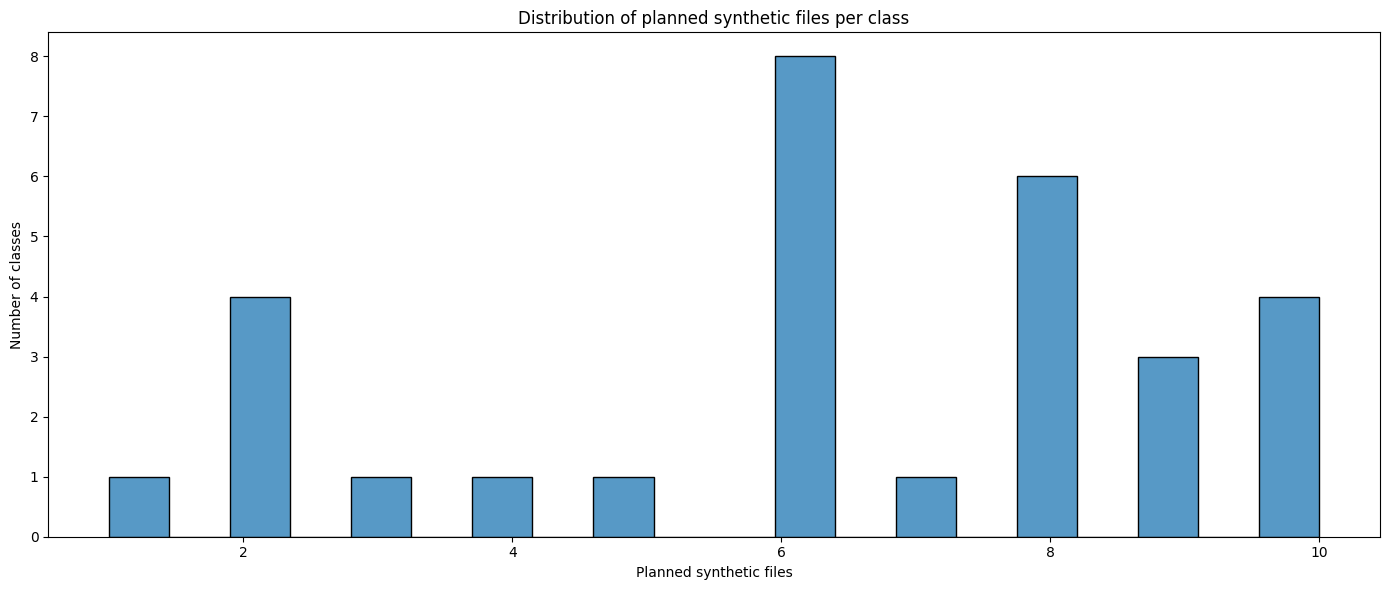

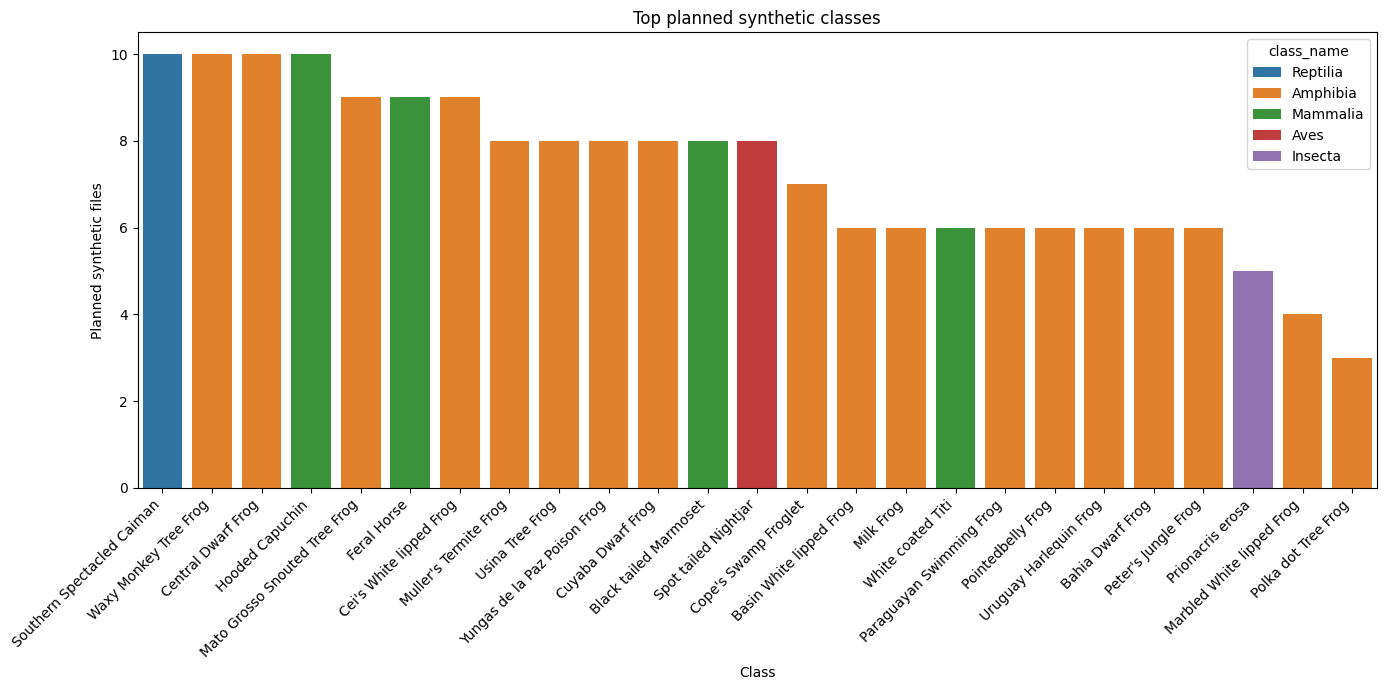

In [21]:
if len(generation_plan) > 0:
    planned_counts = (
        generation_plan.groupby(["primary_label", "prompt_label", "class_name"])
        .size()
        .reset_index(name="planned_synthetic_count")
        .sort_values("planned_synthetic_count", ascending=False)
    )

    display(planned_counts.head(30))
    planned_counts.to_csv(METADATA_DIR / "planned_synthetic_counts_by_class.csv", index=False)

    plt.figure(figsize=(14, 6))
    sns.histplot(planned_counts["planned_synthetic_count"], bins=20)
    plt.title("Distribution of planned synthetic files per class")
    plt.xlabel("Planned synthetic files")
    plt.ylabel("Number of classes")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "planned_synthetic_files_per_class_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(14, 7))
    top_planned = planned_counts.head(25)
    sns.barplot(data=top_planned, x="prompt_label", y="planned_synthetic_count", hue="class_name")
    plt.title("Top planned synthetic classes")
    plt.xlabel("Class")
    plt.ylabel("Planned synthetic files")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "top_planned_synthetic_classes.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No synthetic files planned. Check TARGET_MIN_PER_CLASS / MAX_TOTAL_SYNTH_FILES.")

## 8. Load AudioLDM2 pipeline

This step downloads/loads the AudioLDM2 model.  
It can take a few minutes on first run.

In [22]:
from diffusers import AudioLDM2Pipeline
from transformers import GPT2LMHeadModel

device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

print("Loading AudioLDM2 model:", MODEL_ID)
print("Device:", device)
print("Torch dtype:", torch_dtype)

# ---------------------------------------------------------------------
# IMPORTANT FIX:
# cvssp/audioldm2 may load language_model as GPT2Model.
# Recent diffusers expects GPT2LMHeadModel for AudioLDM2 generation.
# So we explicitly load the language_model as GPT2LMHeadModel and pass it
# into AudioLDM2Pipeline.from_pretrained().
# ---------------------------------------------------------------------
language_model = GPT2LMHeadModel.from_pretrained(
    MODEL_ID,
    subfolder="language_model",
    torch_dtype=torch_dtype
)

pipe = AudioLDM2Pipeline.from_pretrained(
    MODEL_ID,
    language_model=language_model,
    torch_dtype=torch_dtype
)

pipe = pipe.to(device)

try:
    pipe.enable_attention_slicing()
    print("Attention slicing enabled.")
except Exception as e:
    print("Attention slicing not available:", e)

print("✓ AudioLDM2 pipeline ready.")
print("Loaded language model type:", type(pipe.language_model))

Loading AudioLDM2 model: cvssp/audioldm2
Device: cpu
Torch dtype: torch.float32


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/11 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/555 [00:00<?, ?it/s]

[transformers] You are using a model of type `hifigan` to instantiate a model of type `speecht5_hifigan`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Attention slicing enabled.
✓ AudioLDM2 pipeline ready.
Loaded language model type: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'>


## 9. Resume-safe generation status helpers

In [23]:
status_path = STATUS_DIR / "generation_status.csv"

def load_status():
    if status_path.exists():
        df = pd.read_csv(status_path)
        # Keep last status per filename
        if "filename" in df.columns:
            df = df.drop_duplicates(subset=["filename"], keep="last")
        return df
    return pd.DataFrame(columns=[
        "filename",
        "filepath",
        "primary_label",
        "status",
        "created_at",
        "updated_at",
        "error",
        "file_size_bytes"
    ])


def save_status_row(row_dict):
    existing = load_status()
    row_df = pd.DataFrame([row_dict])
    updated = pd.concat([existing, row_df], ignore_index=True)
    updated = updated.drop_duplicates(subset=["filename"], keep="last")
    updated.to_csv(status_path, index=False)


def audio_file_is_valid(filepath):
    p = Path(filepath)
    return p.exists() and p.stat().st_size > 1000


def is_completed(filename, filepath, status_df):
    if SKIP_EXISTING_AUDIO and audio_file_is_valid(filepath):
        return True

    if status_df.empty:
        return False

    match = status_df[status_df["filename"] == filename]
    if match.empty:
        return False

    last = match.iloc[-1]
    return str(last.get("status", "")).lower() == "completed" and audio_file_is_valid(filepath)


def normalize_audio(audio):
    audio = np.asarray(audio, dtype=np.float32).reshape(-1)
    audio = np.nan_to_num(audio, nan=0.0, posinf=0.0, neginf=0.0)

    max_abs = float(np.max(np.abs(audio))) if len(audio) else 0.0
    if max_abs > 1.0:
        audio = audio / max_abs

    audio = np.clip(audio, -1.0, 1.0)
    return audio


def generate_one_audio(prompt, negative_prompt, seed, output_path):
    generator = torch.Generator(device=device).manual_seed(int(seed))

    kwargs = {
        "prompt": prompt,
        "num_inference_steps": int(NUM_INFERENCE_STEPS),
        "audio_length_in_s": float(AUDIO_DURATION_SECONDS),
        "guidance_scale": float(GUIDANCE_SCALE),
        "generator": generator,
    }

    # Some pipeline versions support negative_prompt; if not, retry without it.
    try:
        result = pipe(
            negative_prompt=negative_prompt,
            **kwargs
        )
    except TypeError:
        result = pipe(**kwargs)

    audio = normalize_audio(result.audios[0])

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    sf.write(output_path, audio, OUTPUT_SAMPLE_RATE, subtype="PCM_16")
    return output_path


status_df = load_status()
print("Status file:", status_path)
print("Existing status rows:", len(status_df))

if len(status_df) > 0:
    display(status_df["status"].value_counts(dropna=False))

Status file: /content/drive/MyDrive/audio_assignment/PartB_Method1/status/generation_status.csv
Existing status rows: 32


,count
status,
failed,32


## 10. Generate synthetic audio

This loop is resume-safe.

If the notebook stops:

1. Reconnect runtime.
2. Run all cells again.
3. Completed files are skipped.
4. Only missing files continue generating.

In [24]:
if len(generation_plan) == 0:
    print("No planned synthetic files. Nothing to generate.")
else:
    status_df = load_status()

    pending_rows = []
    completed_count = 0

    for _, row in generation_plan.iterrows():
        filename = row["filename"]
        filepath = row["filepath"]

        if is_completed(filename, filepath, status_df):
            completed_count += 1
        else:
            pending_rows.append(row)

    if MAX_FILES_THIS_RUN is not None:
        pending_rows = pending_rows[:int(MAX_FILES_THIS_RUN)]

    print("Planned files:", len(generation_plan))
    print("Already completed:", completed_count)
    print("Pending this run:", len(pending_rows))

    generation_start = time.time()

    for row in tqdm(pending_rows, desc="Generating AudioLDM2 synthetic audio"):
        filename = row["filename"]
        filepath = row["filepath"]
        primary_label = row["primary_label"]

        started_at = now_iso()

        try:
            output_path = generate_one_audio(
                prompt=row["prompt_text"],
                negative_prompt=row.get("negative_prompt", NEGATIVE_PROMPT),
                seed=int(row["seed"]),
                output_path=filepath
            )

            size_bytes = int(Path(output_path).stat().st_size)

            save_status_row({
                "filename": filename,
                "filepath": filepath,
                "primary_label": primary_label,
                "status": "completed",
                "created_at": started_at,
                "updated_at": now_iso(),
                "error": "",
                "file_size_bytes": size_bytes,
            })

        except Exception as e:
            err = repr(e)
            print("\nGeneration failed for:", filename)
            print(err)
            traceback.print_exc(limit=2)

            save_status_row({
                "filename": filename,
                "filepath": filepath,
                "primary_label": primary_label,
                "status": "failed",
                "created_at": started_at,
                "updated_at": now_iso(),
                "error": err,
                "file_size_bytes": 0,
            })

    print("Generation loop finished in minutes:", round((time.time() - generation_start) / 60, 2))

Planned files: 191
Already completed: 0
Pending this run: 191


Generating AudioLDM2 synthetic audio:   0%|          | 0/191 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Generation loop finished in minutes: 464.55


## 11. Build final synthetic metadata CSV

This file is used by **B1-02** for BirdNET embedding extraction:

```text
/content/drive/MyDrive/audio_assignment/PartB_Method1/metadata/synthetic_metadata.csv
```

In [25]:
status_df = load_status()

completed_status = status_df[
    status_df["status"].astype(str).str.lower() == "completed"
].copy()

completed_files = set(completed_status["filename"].astype(str).tolist())

synthetic_metadata = generation_plan[
    generation_plan["filename"].astype(str).isin(completed_files)
].copy()

# Validate physical file existence too
synthetic_metadata["file_exists"] = synthetic_metadata["filepath"].apply(lambda p: Path(p).exists())
synthetic_metadata["file_size_bytes"] = synthetic_metadata["filepath"].apply(
    lambda p: Path(p).stat().st_size if Path(p).exists() else 0
)

synthetic_metadata = synthetic_metadata[
    (synthetic_metadata["file_exists"] == True)
    & (synthetic_metadata["file_size_bytes"] > 1000)
].reset_index(drop=True)

synthetic_metadata_path = METADATA_DIR / "synthetic_metadata.csv"
synthetic_metadata.to_csv(synthetic_metadata_path, index=False)

print("Saved synthetic metadata:", synthetic_metadata_path)
print("Completed usable synthetic files:", len(synthetic_metadata))
print("Classes with completed synthetic files:", synthetic_metadata["primary_label"].nunique() if len(synthetic_metadata) else 0)

display(synthetic_metadata.head(20))

summary = {
    "created_at": now_iso(),
    "model_id": MODEL_ID,
    "output_format": OUTPUT_FORMAT,
    "output_sample_rate": int(OUTPUT_SAMPLE_RATE),
    "audio_duration_seconds": float(AUDIO_DURATION_SECONDS),
    "num_inference_steps": int(NUM_INFERENCE_STEPS),
    "guidance_scale": float(GUIDANCE_SCALE),
    "planned_files": int(len(generation_plan)),
    "completed_usable_files": int(len(synthetic_metadata)),
    "completed_classes": int(synthetic_metadata["primary_label"].nunique()) if len(synthetic_metadata) else 0,
    "metadata_path": str(synthetic_metadata_path),
    "status_path": str(status_path),
    "split_policy": "Synthetic files are training-only. Validation remains original A Method 1 validation embeddings.",
}

with open(METADATA_DIR / "synthetic_generation_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print(json.dumps(summary, indent=4))

Saved synthetic metadata: /content/drive/MyDrive/audio_assignment/PartB_Method1/metadata/synthetic_metadata.csv
Completed usable synthetic files: 191
Classes with completed synthetic files: 30


,primary_label,split,source,synthetic_index,filename,filepath,seed,train_count,validation_count,is_validation_only_class,...,class_name,prompt_text,negative_prompt,output_format,duration_seconds,sample_rate,num_inference_steps,guidance_scale,file_exists,file_size_bytes
0,116570,synthetic_train,synthetic_audioldm2,0,116570/synthetic_116570_0000.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1085472573,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
1,116570,synthetic_train,synthetic_audioldm2,1,116570/synthetic_116570_0001.wav,/content/drive/MyDrive/audio_assignment/PartB_...,4185610019,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
2,116570,synthetic_train,synthetic_audioldm2,2,116570/synthetic_116570_0002.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1360425530,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
3,116570,synthetic_train,synthetic_audioldm2,3,116570/synthetic_116570_0003.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1225279933,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
4,116570,synthetic_train,synthetic_audioldm2,4,116570/synthetic_116570_0004.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1946685325,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
5,116570,synthetic_train,synthetic_audioldm2,5,116570/synthetic_116570_0005.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2756706536,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
6,116570,synthetic_train,synthetic_audioldm2,6,116570/synthetic_116570_0006.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2395706969,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
7,116570,synthetic_train,synthetic_audioldm2,7,116570/synthetic_116570_0007.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2506193722,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
8,116570,synthetic_train,synthetic_audioldm2,8,116570/synthetic_116570_0008.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2402390970,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
9,116570,synthetic_train,synthetic_audioldm2,9,116570/synthetic_116570_0009.wav,/content/drive/MyDrive/audio_assignment/PartB_...,2729174608,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044


{
    "created_at": "2026-06-17T19:25:53",
    "model_id": "cvssp/audioldm2",
    "output_format": "wav",
    "output_sample_rate": 16000,
    "audio_duration_seconds": 5.0,
    "num_inference_steps": 25,
    "guidance_scale": 3.5,
    "planned_files": 191,
    "completed_usable_files": 191,
    "completed_classes": 30,
    "metadata_path": "/content/drive/MyDrive/audio_assignment/PartB_Method1/metadata/synthetic_metadata.csv",
    "status_path": "/content/drive/MyDrive/audio_assignment/PartB_Method1/status/generation_status.csv",
    "split_policy": "Synthetic files are training-only. Validation remains original A Method 1 validation embeddings."
}


,primary_label,prompt_label,class_name,completed_synthetic_count
1,116570,Southern Spectacled Caiman,Reptilia,10
13,23724,Waxy Monkey Tree Frog,Amphibia,10
10,23150,Central Dwarf Frog,Amphibia,10
18,516975,Hooded Capuchin,Mammalia,10
15,24321,Mato Grosso Snouted Tree Frog,Amphibia,9
4,209233,Feral Horse,Mammalia,9
24,70711,Cei's White lipped Frog,Amphibia,9
16,25214,Muller's Termite Frog,Amphibia,8
19,555123,Usina Tree Frog,Amphibia,8
21,64898,Yungas de la Paz Poison Frog,Amphibia,8


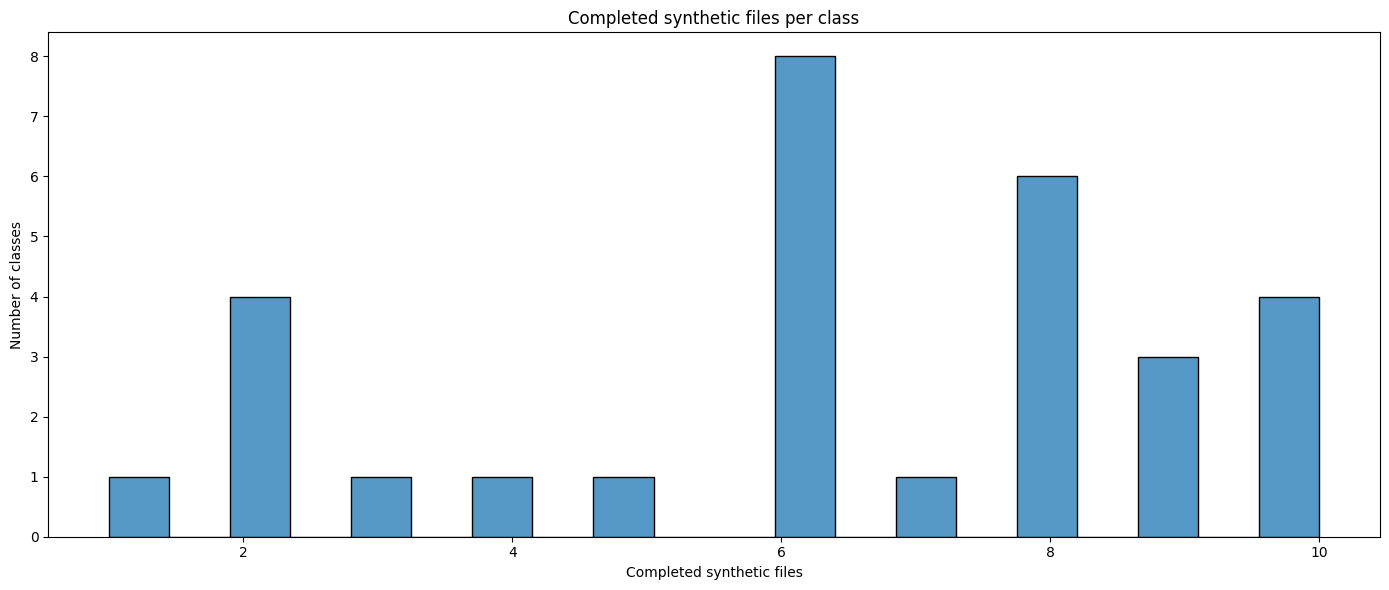

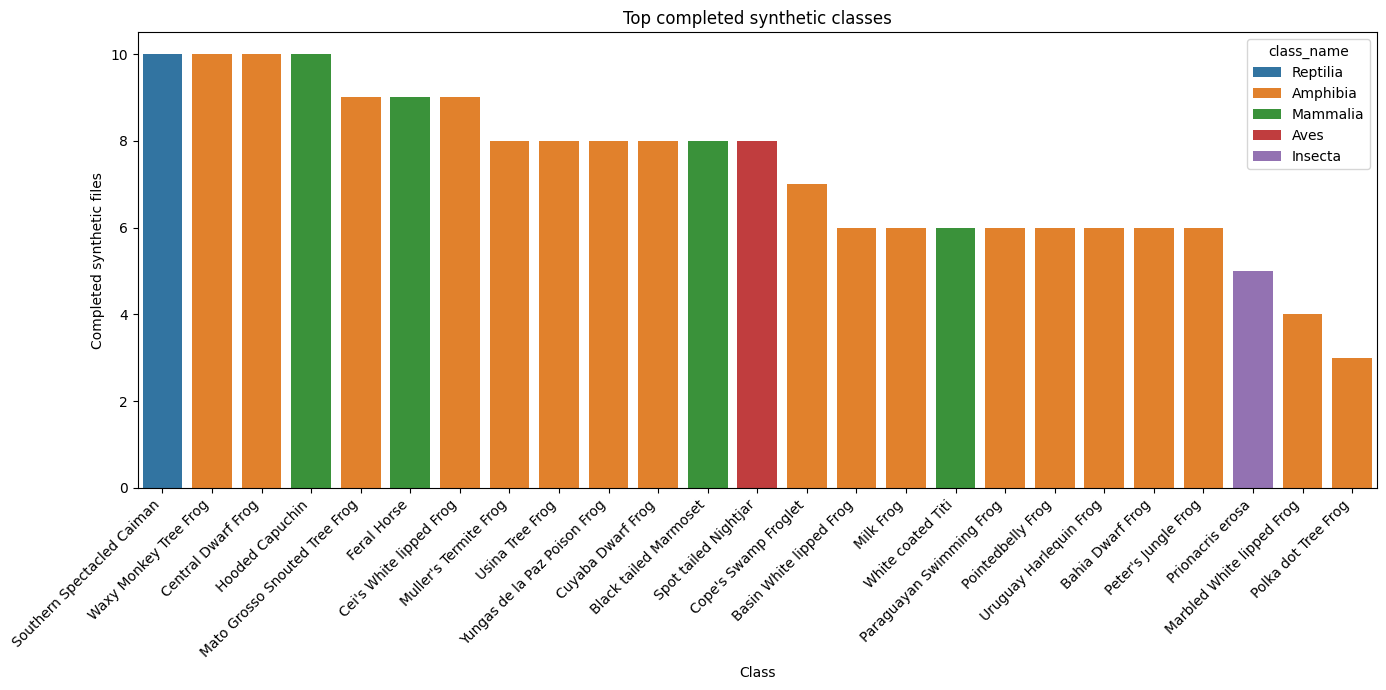

In [26]:
if len(synthetic_metadata) > 0:
    completed_counts = (
        synthetic_metadata.groupby(["primary_label", "prompt_label", "class_name"])
        .size()
        .reset_index(name="completed_synthetic_count")
        .sort_values("completed_synthetic_count", ascending=False)
    )

    completed_counts.to_csv(METADATA_DIR / "completed_synthetic_counts_by_class.csv", index=False)
    display(completed_counts.head(30))

    plt.figure(figsize=(14, 6))
    sns.histplot(completed_counts["completed_synthetic_count"], bins=20)
    plt.title("Completed synthetic files per class")
    plt.xlabel("Completed synthetic files")
    plt.ylabel("Number of classes")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "completed_synthetic_files_per_class_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(14, 7))
    top_completed = completed_counts.head(25)
    sns.barplot(data=top_completed, x="prompt_label", y="completed_synthetic_count", hue="class_name")
    plt.title("Top completed synthetic classes")
    plt.xlabel("Class")
    plt.ylabel("Completed synthetic files")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "top_completed_synthetic_classes.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No completed synthetic metadata yet.")

## 12. Optional: listen to a few generated files

Run this only after at least a few synthetic files are generated.

In [27]:
from IPython.display import Audio, display

N_PREVIEW = 3

if len(synthetic_metadata) == 0:
    print("No synthetic files available to preview.")
else:
    preview_df = synthetic_metadata.sample(min(N_PREVIEW, len(synthetic_metadata)), random_state=BASE_SEED)

    for _, row in preview_df.iterrows():
        print("=" * 80)
        print("Label:", row["primary_label"])
        print("Prompt label:", row["prompt_label"])
        print("Class:", row["class_name"])
        print("Prompt:", row["prompt_text"])
        print("File:", row["filepath"])
        display(Audio(row["filepath"]))

Label: 23154
Prompt label: Bahia Dwarf Frog
Class: Amphibia
Prompt: A clear realistic field recording of a Bahia Dwarf Frog (Physalaemus albifrons) frog or amphibian vocalisation, natural frog call, single target animal, wetland or outdoor habitat, bioacoustic recording, no human speech, no music.
File: /content/drive/MyDrive/audio_assignment/PartB_Method1/synthetic_audio/23154/synthetic_23154_0000.wav


Label: 476521
Prompt label: Cuyaba Dwarf Frog
Class: Amphibia
Prompt: A clear realistic field recording of a Cuyaba Dwarf Frog (Physalaemus nattereri) frog or amphibian vocalisation, natural frog call, single target animal, wetland or outdoor habitat, bioacoustic recording, no human speech, no music.
File: /content/drive/MyDrive/audio_assignment/PartB_Method1/synthetic_audio/476521/synthetic_476521_0000.wav


Label: 66971
Prompt label: Paraguayan Swimming Frog
Class: Amphibia
Prompt: A clear realistic field recording of a Paraguayan Swimming Frog (Pseudis platensis) frog or amphibian vocalisation, natural frog call, single target animal, wetland or outdoor habitat, bioacoustic recording, no human speech, no music.
File: /content/drive/MyDrive/audio_assignment/PartB_Method1/synthetic_audio/66971/synthetic_66971_0000.wav


## 13. Final check before B1-02

Before running **B1-02**, make sure this file exists and has rows:

```text
/content/drive/MyDrive/audio_assignment/PartB_Method1/metadata/synthetic_metadata.csv
```

B1-02 will use this file to extract BirdNET embeddings from the generated synthetic WAV files.

In [28]:
print("Synthetic metadata path:", synthetic_metadata_path)
print("Exists:", synthetic_metadata_path.exists())
print("Rows:", len(synthetic_metadata) if 'synthetic_metadata' in globals() else "not created")

if synthetic_metadata_path.exists():
    check_df = pd.read_csv(synthetic_metadata_path)
    display(check_df.head())
    print("Rows in saved metadata:", len(check_df))
    print("Unique labels:", check_df["primary_label"].nunique() if len(check_df) else 0)

Synthetic metadata path: /content/drive/MyDrive/audio_assignment/PartB_Method1/metadata/synthetic_metadata.csv
Exists: True
Rows: 191


,primary_label,split,source,synthetic_index,filename,filepath,seed,train_count,validation_count,is_validation_only_class,...,class_name,prompt_text,negative_prompt,output_format,duration_seconds,sample_rate,num_inference_steps,guidance_scale,file_exists,file_size_bytes
0,116570,synthetic_train,synthetic_audioldm2,0,116570/synthetic_116570_0000.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1085472573,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
1,116570,synthetic_train,synthetic_audioldm2,1,116570/synthetic_116570_0001.wav,/content/drive/MyDrive/audio_assignment/PartB_...,4185610019,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
2,116570,synthetic_train,synthetic_audioldm2,2,116570/synthetic_116570_0002.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1360425530,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
3,116570,synthetic_train,synthetic_audioldm2,3,116570/synthetic_116570_0003.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1225279933,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044
4,116570,synthetic_train,synthetic_audioldm2,4,116570/synthetic_116570_0004.wav,/content/drive/MyDrive/audio_assignment/PartB_...,1946685325,0,1,True,...,Reptilia,A clear realistic field recording of a Souther...,"human speech, talking, music, instruments, tra...",wav,5.0,16000,25,3.5,True,160044


Rows in saved metadata: 191
Unique labels: 30
